## Part c): Testing against other software libraries
You should test your results against a similar code using Scikit-Learn (see the examples in the above lecture notes from weeks 41 and 42) or tensorflow/keras or Pytorch (for Pytorch, see Raschka et al.’s text chapters 12 and 13).

In [60]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
import numpy as np
import autograd as ad
from autograd import grad, elementwise_grad
import autograd.numpy as anp 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings('ignore')
warnings.filterwarnings('ignore')



In [61]:
from functions import (
    cost, create_layers_batch, feed_forward_batch, feed_forward_saver_batch,
    backpropagation_batch, polynomial_features, plot_accuracy
)
from activations import (
    sigmoid, ReLU, leaky_ReLu, sigmoid_der, ReLU_der, leaky_ReLU_der, softmax, softmax_der
)
from costs import (
    mse, mse_der, cross_entropy, binary_cross_entropy_loss,
    binary_cross_entropy_loss_l1, binary_cross_entropy_loss_l2,
    multiclass_cross_entropy_loss, crossentropy_der
)
from train_funct import (
    train_network, train_network_SGD_momentum, train_network_RMSprop, train_network_ADAM
)

## Test derivations: manual versus scikit-learn library

In [62]:
def feed_forward_one_layer(W, b, x):
    z = W @ x  + b
    a = sigmoid(z)
    return a

def cost_one_layer(W, b, x, target):
    predict = feed_forward_one_layer(W, b, x)
    return mse(predict, target)

In [63]:
num_inp = 2
num_out = 3

x = np.random.rand(num_inp)
target = np.random.rand(num_out)

W = np.random.randn(num_out, num_inp)
b = np.random.randn(num_out)

# feed forward one layer
predict = feed_forward_one_layer(W, b, x)

print('MSE manual: ', mse_der(predict, target), '\n')

autograd_one_layer = grad(cost_one_layer, [0, 1])
W_g, b_g = autograd_one_layer(W, b, x, target)

cost_autograd = grad(mse, 0)
print('MSE autograd: ',cost_autograd(predict, target), '\n')

#Derivation comparison
dC_da = (predict - target)/3*2
dC_dz = dC_da * (predict * (1 - predict))
dC_dW =  np.outer(dC_dz, x)
dC_db = dC_dz

print('dC_dW, dC_db manual: ', dC_dW, dC_db, '\n')

W_g, b_g = autograd_one_layer(W, b, x, target)
print('dC_dW, dC_db autograd: ', W_g, b_g , '\n')

MSE manual:  [ 0.01187491 -0.38594526  0.06422087] 

MSE autograd:  [ 0.01187491 -0.38594526  0.06422087] 

dC_dW, dC_db manual:  [[ 0.00191428  0.00058366]
 [-0.04840195 -0.01475755]
 [ 0.01039503  0.0031694 ]] [ 0.00294651 -0.07450131  0.01600025] 

dC_dW, dC_db autograd:  [[ 0.00191428  0.00058366]
 [-0.04840195 -0.01475755]
 [ 0.01039503  0.0031694 ]] [ 0.00294651 -0.07450131  0.01600025] 



# Scikit-Learn

In [64]:
# -----------------
# 1) Data (Runge + noise)
# -----------------
np.random.seed(41)
n = 200
x = np.random.uniform(-1, 1, n)
y = 1.0 / (1 + 25 * x**2) + np.random.normal(0, 0.1, x.shape)

# Standardize x for visual comparability (like your baseline did)
x_mean = np.mean(x)
x_std = np.std(x, ddof=1)
x_st = (x - x_mean) / x_std

X = x_st.reshape(-1, 1)
y = y.reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [65]:
def scikitlearn_NN(X_train,X_test, y_train, y_test, poly_degree, learning_rate, hidden_layers, activation_fun, grad_dis_type ):
    pre = Pipeline([
    ("poly", PolynomialFeatures(degree=poly_degree, include_bias=True)),
    ("scaler", StandardScaler())])

    Xtr = pre.fit_transform(X_train)
    Xte = pre.transform(X_test)
        
    # Option A: SGD with momentum (closest to train_network_SGD_momentum)
    reg = MLPRegressor(
        hidden_layer_sizes=hidden_layers,
        activation= activation_fun,        # output layer  ReLU
        solver= grad_dis_type,
        learning_rate_init=learning_rate,
        momentum=0.8,             
        max_iter=1000,               
        warm_start=True,         
        shuffle=True,
        random_state=42
    )
    
    reg.fit(Xtr, y_train)  
    ytr_pred = reg.predict(Xtr)
    yte_pred = reg.predict(Xte)
    tr_mse = mean_squared_error(y_train, ytr_pred)
    te_mse = mean_squared_error(y_test, yte_pred)

    return tr_mse, te_mse

## SGD with relu

In [66]:
# 1 layer

learning_rates = [1e-4, 1e-3, 1e-2, 1e-1]

for learning_rate in learning_rates:
    train_mse, test_mse = scikitlearn_NN(
        X_train,X_test,
        y_train, y_test,
        poly_degree = 7, 
        learning_rate = learning_rate, 
        hidden_layers = (50,), 
        activation_fun= 'relu',
        grad_dis_type = 'sgd')
    print(f"lr={learning_rate:<8g}  train MSE={train_mse:.6f}  test MSE={test_mse:.6f}")


lr=0.0001    train MSE=0.153121  test MSE=0.230303
lr=0.001     train MSE=0.062882  test MSE=0.094625
lr=0.01      train MSE=0.025841  test MSE=0.051244
lr=0.1       train MSE=0.015705  test MSE=0.029504


In [67]:
# 2 layers

for learning_rate in learning_rates:
    train_mse, test_mse = scikitlearn_NN(
        X_train,X_test,
        y_train, y_test,
        poly_degree = 7, 
        learning_rate = learning_rate, 
        hidden_layers = (100,100,), 
        activation_fun= 'relu',
        grad_dis_type = 'sgd')
    print(f"lr={learning_rate:<8g}  train MSE={train_mse:.6f}  test MSE={test_mse:.6f}")


lr=0.0001    train MSE=0.087839  test MSE=0.137785
lr=0.001     train MSE=0.041407  test MSE=0.084704
lr=0.01      train MSE=0.026423  test MSE=0.055340
lr=0.1       train MSE=0.017344  test MSE=0.033133


## Adam 

In [68]:
# 1 layer
for learning_rate in learning_rates:
    train_mse, test_mse = scikitlearn_NN(
        X_train,X_test,
        y_train, y_test,
        poly_degree = 7, 
        learning_rate = learning_rate, 
        hidden_layers = (50,), 
        activation_fun= 'relu',
        grad_dis_type = 'adam')
    print(f"lr={learning_rate:<8g}  train MSE={train_mse:.6f}  test MSE={test_mse:.6f}")


lr=0.0001    train MSE=0.052720  test MSE=0.085492
lr=0.001     train MSE=0.018300  test MSE=0.037662
lr=0.01      train MSE=0.013778  test MSE=0.025157
lr=0.1       train MSE=0.011723  test MSE=0.020636


In [69]:
# 2 layers
for learning_rate in learning_rates:
    train_mse, test_mse = scikitlearn_NN(
        X_train,X_test,
        y_train, y_test,
        poly_degree = 7, 
        learning_rate = learning_rate, 
        hidden_layers = (100,100,), 
        activation_fun= 'relu',
        grad_dis_type = 'adam')
    print(f"lr={learning_rate:<8g}  train MSE={train_mse:.6f}  test MSE={test_mse:.6f}")


lr=0.0001    train MSE=0.028716  test MSE=0.061354
lr=0.001     train MSE=0.014095  test MSE=0.026578
lr=0.01      train MSE=0.009162  test MSE=0.015568
lr=0.1       train MSE=0.926375  test MSE=0.473343


# Pytorch

In [70]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def polynomial_features(x, p):
    n = len(x)
    X = np.zeros((n, p + 1))
    X[:, 0] = 1
    for i in range(1, p + 1):
        X[:, i] = x ** i
    return X

def print_output(results, gd_type=''):
    print(f"\n=== Learning rate summary {gd_type} ===")
    for lr, train_mse, test_mse in results:
        print(f"lr={lr:<8}  train MSE={train_mse:.6f}  test MSE={test_mse:.6f}")

class NeuralNetwork(nn.Module):
    def __init__(self, input_size, layer_sizes, activation_funcs):

        super(NeuralNetwork, self).__init__()
        
        self.layers = nn.ModuleList()
        prev_size = input_size
        
        for size in layer_sizes:
            self.layers.append(nn.Linear(prev_size, size))
            prev_size = size
        
        self.activations = []

        for func_name in activation_funcs:
            if func_name == 'sigmoid':
                self.activations.append(nn.Sigmoid())
            elif func_name == 'relu':
                self.activations.append(nn.ReLU())
            else:
                self.activations.append(nn.Identity())
    
    def forward(self, x):
        for layer, activation in zip(self.layers, self.activations):
            x = layer(x)
            x = activation(x)
        return x

def train_network_pytorch(model, X_train, y_train, optimizer, criterion, epochs=1000, verbose=False):
    model.train()
    mse_history = []
    
    X_train = X_train.to(device)
    y_train = y_train.to(device)
    
    for epoch in range(epochs):
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        mse_history.append(loss.item())
        
        if verbose and (epoch + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.6f}')
    
    return mse_history

def train_network_RMSprop_pytorch(model, X_train, y_train, learning_rate, criterion, epochs=1000, alpha=0.9, eps=1e-6):
    optimizer = optim.RMSprop(model.parameters(), lr=learning_rate, alpha=alpha, eps=eps)
    return train_network_pytorch(model, X_train, y_train, optimizer, criterion, epochs)

def evaluate_model(model, X, y, criterion):
    model.eval()
    with torch.no_grad():
        X = X.to(device)
        y = y.to(device)
        outputs = model(X)
        loss = criterion(outputs, y)
    return loss.item()

def calculate_nlayer_nn_pytorch(inputs_train, targets_train, inputs_test, targets_test,
                                n_iter, learning_rates, network_input_size, 
                                layer_output_sizes, activation_funcs, 
                                train_network_type='adam'):
    
    results = []
    histories = []
    criterion = nn.MSELoss()
    
    activation_names = []
    for func in activation_funcs:
        if func.__name__ == 'sigmoid':
            activation_names.append('sigmoid')
        elif func.__name__ == 'ReLU':
            activation_names.append('relu')
        elif func.__name__ == 'leaky_ReLu':
            activation_names.append('leaky_relu')
        else:
            activation_names.append('relu')  # default
    
    X_train_tensor = torch.FloatTensor(inputs_train)
    y_train_tensor = torch.FloatTensor(targets_train)
    X_test_tensor = torch.FloatTensor(inputs_test)
    y_test_tensor = torch.FloatTensor(targets_test)
    
    for lr in learning_rates:
        model = NeuralNetwork(network_input_size, layer_output_sizes, activation_names).to(device)
        
        history = train_network_RMSprop_pytorch(model, X_train_tensor, y_train_tensor, lr, criterion, epochs=n_iter)
        
        train_mse = evaluate_model(model, X_train_tensor, y_train_tensor, criterion)
        test_mse = evaluate_model(model, X_test_tensor, y_test_tensor, criterion)
        
        results.append((lr, train_mse, test_mse))
        histories.append(history)
    
    return results, histories

poly_degree = 7
inputs_train = np.array(polynomial_features(X_train.ravel(), poly_degree))
targets_train = y_train.reshape(-1, 1)

inputs_test = np.array(polynomial_features(X_test.ravel(), poly_degree))
targets_test = y_test.reshape(-1, 1)

n_iter = 1000
network_input_size = poly_degree + 1
layer_output_sizes = [100, 100, 1]
    
activation_funcs = [sigmoid, sigmoid, ReLU]
activation_ders = [sigmoid_der, sigmoid_der, ReLU_der]

results, histories_best = calculate_nlayer_nn_pytorch(
    inputs_train=inputs_train,
    targets_train=targets_train,
    inputs_test=inputs_test,
    targets_test=targets_test,
    n_iter=1000,
    learning_rates=[1e-4],
    network_input_size=network_input_size,
    layer_output_sizes=[100, 100, 1],
    activation_funcs=activation_funcs,
    train_network_type='rmsprop'
)

print_output(results, gd_type='RMSprop (PyTorch)')



=== Learning rate summary RMSprop (PyTorch) ===
lr=0.0001    train MSE=0.138633  test MSE=0.195214


# Experimental:

## This model optimizes the squared error using LBFGS or stochastic gradient descent.

**activation funct: ** 

‘logistic’, the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).

‘relu’, the rectified linear unit function, returns f(x) = max(0, x)



In [71]:
# Preprocessor: PolynomialFeatures + StandardScaler
poly_degree = 7
pre = Pipeline([
    ("poly", PolynomialFeatures(degree=poly_degree, include_bias=True)),
    ("scaler", StandardScaler())
])

Xtr = pre.fit_transform(X_train)
Xte = pre.transform(X_test)

# NN model with SGD 
n_iter = 1000       # number of iterations
lr = 0.01           # learning rate
hidden = (100,100,)      # 2 hidden layer with 50 nodes 

# Option A: SGD with momentum (closest to train_network_SGD_momentum)
reg = MLPRegressor(
    hidden_layer_sizes=hidden,
    activation="relu",        # output layer  ReLU
    solver="sgd",
    learning_rate_init=lr,
    momentum=0.8,             
    max_iter=1,               
    warm_start=True,         
    shuffle=True,
    random_state=42
)

train_mse_hist, test_mse_hist = [], []

# for plots & train
for epoch in range(1, n_iter + 1):
    reg.fit(Xtr, y_train.ravel())  # one epoch
    ytr_pred = reg.predict(Xtr)
    yte_pred = reg.predict(Xte)
    tr_mse = mean_squared_error(y_train, ytr_pred)
    te_mse = mean_squared_error(y_test, yte_pred)
    train_mse_hist.append(tr_mse)
    test_mse_hist.append(te_mse)

# Final metrics
ytr_pred = reg.predict(Xtr)
yte_pred = reg.predict(Xte)
final_train_mse = mean_squared_error(y_train, ytr_pred)
final_test_mse  = mean_squared_error(y_test,  yte_pred)


Final Train MSE: 0.016736
Final Test  MSE: 0.032178 


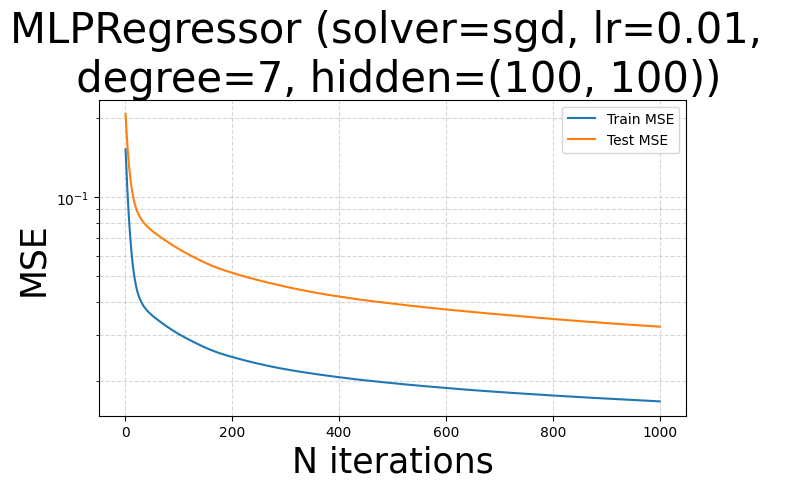

In [72]:
print(f"Final Train MSE: {final_train_mse:.6f}")
print(f"Final Test  MSE: {final_test_mse:.6f} ")

# Plot per-epoch MSE (like your plot_accuracy, but for both train & test)
plt.figure(figsize=(7, 5))
plt.plot(range(1, n_iter + 1), train_mse_hist, label="Train MSE")
plt.plot(range(1, n_iter + 1), test_mse_hist,  label="Test MSE")
plt.yscale("log")
plt.xlabel("N iterations", fontsize = 25)
plt.ylabel("MSE", fontsize = 25)
plt.title(f"MLPRegressor (solver={reg.solver}, lr={lr}, \n degree={poly_degree}, hidden={hidden})", fontsize = 30)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()